# Attention to the previous newline by characters remaining

For every attention head, this notebook plots the mean attention paid to the most recent preceding `_NEWLINE_` token as a function of the number of characters remaining in the current line.

At a content-token query, **characters remaining** is the example's sampled line width minus the cumulative character count through that query token. Thus 0 means the token exactly reaches the boundary, while a negative value means it overshoots it. Newline queries and queries before the first actual newline are excluded.

In [2]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

import project_main.checkpoints as project_checkpoints
import project_main.data as project_data
import project_main.model as project_model
import project_main.tokens as project_tokens

RUN_DIR = Path("../results/line_breaks_results")
CHECKPOINT_PATH = RUN_DIR / "checkpoints" / "final.pt"

N_SEQUENCES = 5_000
COLLECTION_BATCH_SIZE = 256
DATA_SEED = 27_071
NORMALIZE_EACH_HEAD = False
N_PLOT_COLUMNS = 4


/Users/rohanbuluswar/Desktop/Line Break Project/.venv_new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open(RUN_DIR / "config.json", "r") as f:
    cfg = json.load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"
vocab = project_tokens.build_vocab(cfg["task"])
model = project_model.build_model(cfg=cfg, device=device)
checkpoint = project_checkpoints.load_checkpoint(
    path=CHECKPOINT_PATH,
    model=model,
    map_location=device,
)
model.eval()

n_layers = cfg["model"]["n_layers"]
n_heads = cfg["model"]["n_heads"]
_, max_line_width = project_data.get_line_length_range(cfg["task"])
max_token_length = cfg["task"]["num_token_lengths"]
min_characters_remaining = -(max_token_length - 1)
max_characters_remaining = max_line_width - 1
characters_remaining_values = np.arange(
    min_characters_remaining, max_characters_remaining + 1
)

print(f"Loaded checkpoint step {checkpoint['step']} on {device}")
print(f"Model has {n_layers} layers and {n_heads} heads per layer")
print(
    "Possible characters-remaining range: "
    f"{min_characters_remaining} through {max_characters_remaining}"
)


Building vocab...
('BOS', '_NEWLINE_')
Loaded checkpoint step 10000 on cpu
Model has 3 layers and 4 heads per layer
Possible characters-remaining range: -7 through 99


## Collect and aggregate attention patterns

TransformerLens attention patterns have shape `[batch, head, query_position, key_position]`. For each valid content-token query, the code identifies its previous newline key, computes the signed characters remaining, and averages that single attention value within each `(layer, head, characters remaining)` group.

In [4]:
def previous_newline_metadata(
    token_rows: torch.Tensor,
    line_widths: torch.Tensor,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return batch, query, previous-newline key, and remaining characters."""
    batch_indices = []
    query_indices = []
    key_indices = []
    remaining_values = []

    token_rows_list = token_rows.detach().cpu().tolist()
    line_widths_list = line_widths.detach().cpu().tolist()
    for batch_index, (token_row, line_width) in enumerate(
        zip(token_rows_list, line_widths_list)
    ):
        running_character_count = 0
        previous_newline_position = None

        for query_position, token_id in enumerate(token_row):
            if token_id == vocab.newline_id:
                running_character_count = 0
                previous_newline_position = query_position
                continue

            running_character_count += project_data.extract_character_count(
                vocab.decode_token(token_id)
            )
            if previous_newline_position is None:
                continue

            batch_indices.append(batch_index)
            query_indices.append(query_position)
            key_indices.append(previous_newline_position)
            remaining_values.append(line_width - running_character_count)

    return (
        np.asarray(batch_indices, dtype=np.int64),
        np.asarray(query_indices, dtype=np.int64),
        np.asarray(key_indices, dtype=np.int64),
        np.asarray(remaining_values, dtype=np.int64),
    )


@torch.no_grad()
def collect_attention_to_previous_newline(
    n_sequences: int,
    *,
    batch_size: int = COLLECTION_BATCH_SIZE,
    seed: int = DATA_SEED,
) -> tuple[np.ndarray, np.ndarray]:
    """Aggregate attention by layer, head, and characters remaining."""
    n_remaining_values = len(characters_remaining_values)
    attention_sums = np.zeros(
        (n_layers, n_heads, n_remaining_values), dtype=np.float64
    )
    examples_per_value = np.zeros(n_remaining_values, dtype=np.int64)
    pattern_names = [
        f"blocks.{layer}.attn.hook_pattern" for layer in range(n_layers)
    ]

    for start in range(0, n_sequences, batch_size):
        this_batch_size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size,
            vocab=vocab,
            task_cfg=cfg["task"],
            device=device,
            seed=seed + start,
        )
        (
            batch_indices,
            query_indices,
            key_indices,
            remaining_values,
        ) = previous_newline_metadata(batch.tokens, batch.line_lengths)
        if len(remaining_values) == 0:
            continue

        remaining_indices = remaining_values - min_characters_remaining
        if np.any((remaining_indices < 0) | (remaining_indices >= n_remaining_values)):
            raise RuntimeError("Observed characters remaining outside derived bounds.")

        _, cache = model.run_with_cache(
            batch.tokens,
            prepend_bos=False,
            names_filter=lambda name: name in pattern_names,
        )
        np.add.at(examples_per_value, remaining_indices, 1)

        for layer, pattern_name in enumerate(pattern_names):
            pattern = cache[pattern_name].detach().cpu().numpy()
            selected_attention = pattern[
                batch_indices, :, query_indices, key_indices
            ]
            for head in range(n_heads):
                np.add.at(
                    attention_sums[layer, head],
                    remaining_indices,
                    selected_attention[:, head],
                )

    observed = examples_per_value > 0
    mean_attention = np.full_like(attention_sums, np.nan)
    mean_attention[:, :, observed] = (
        attention_sums[:, :, observed]
        / examples_per_value[observed][None, None, :]
    )
    return mean_attention, examples_per_value


In [5]:
mean_attention, examples_per_value = collect_attention_to_previous_newline(
    N_SEQUENCES
)

observed = examples_per_value > 0
if not observed.any():
    raise RuntimeError("No content-token queries with a previous newline were found.")

plot_x = characters_remaining_values[observed]
plot_curves = mean_attention[:, :, observed].copy()
if NORMALIZE_EACH_HEAD:
    head_maxima = np.nanmax(plot_curves, axis=2, keepdims=True)
    plot_curves = plot_curves / np.maximum(head_maxima, 1e-12)

print(
    f"Observed characters remaining: {plot_x.min()} through {plot_x.max()}"
)
print(f"Valid content-token queries: {examples_per_value.sum():,}")
print(
    "Examples per observed value: "
    f"min={examples_per_value[observed].min():,}, "
    f"median={int(np.median(examples_per_value[observed])):,}, "
    f"max={examples_per_value[observed].max():,}"
)


Observed characters remaining: -7 through 99
Valid content-token queries: 619,160
Examples per observed value: min=71, median=7,391, max=8,609


## One panel per attention head

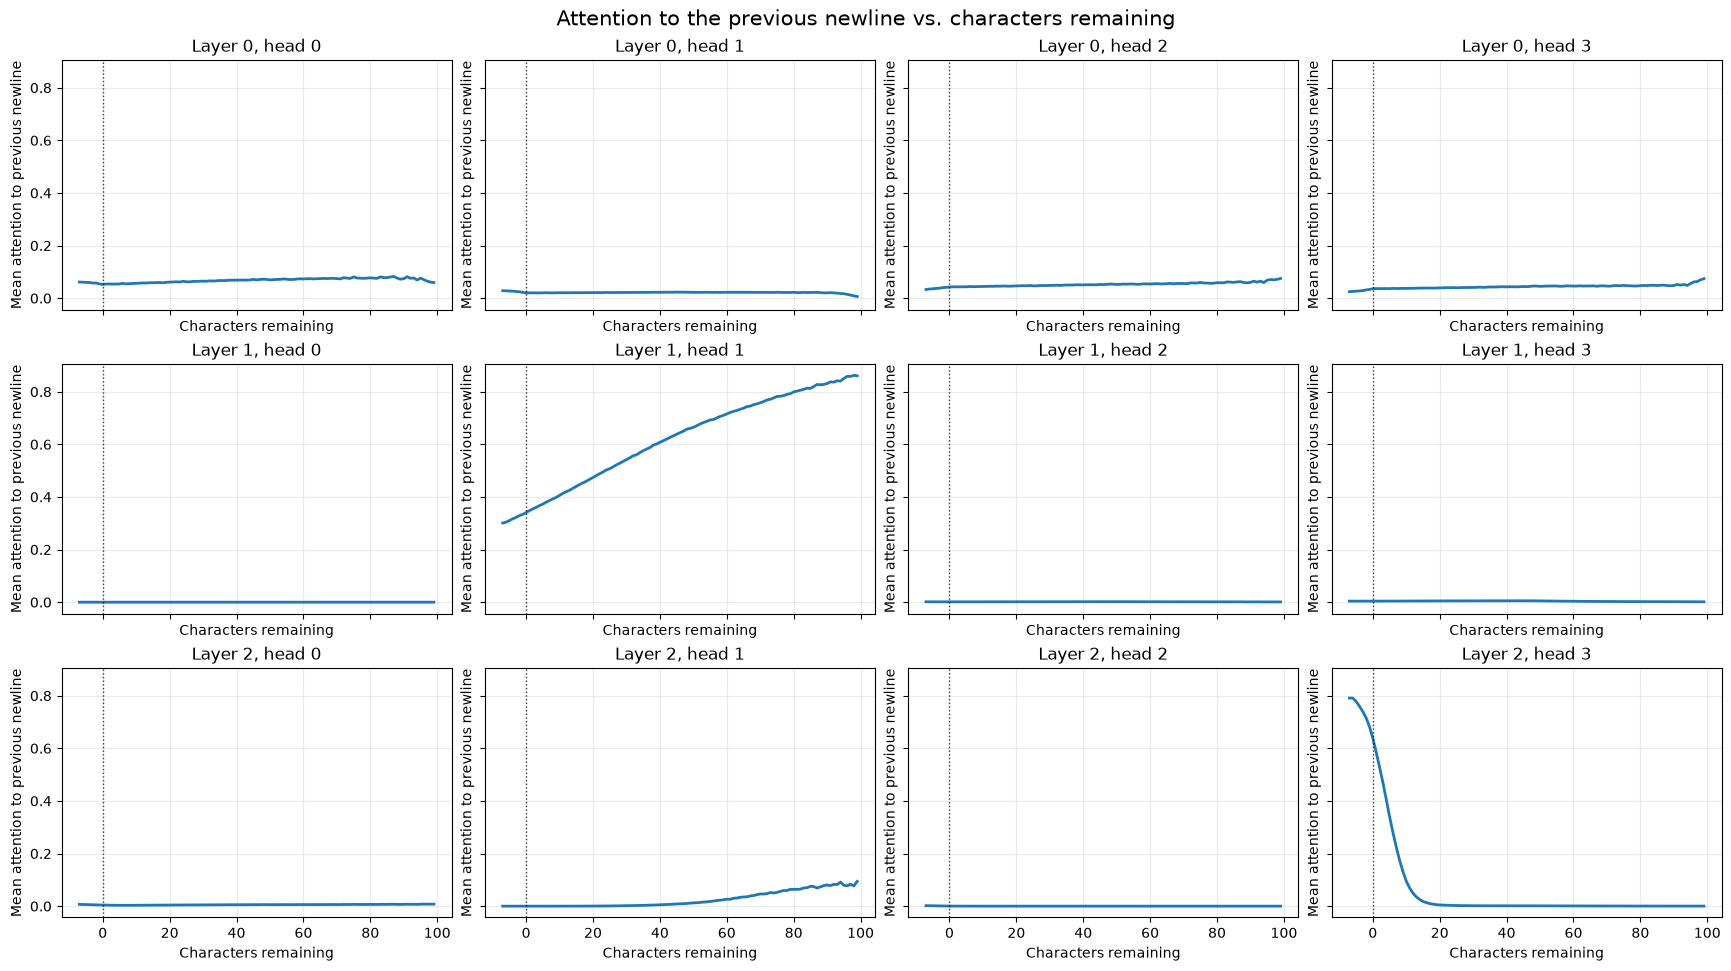

In [6]:
n_panels = n_layers * n_heads
n_columns = min(N_PLOT_COLUMNS, n_panels)
n_rows = math.ceil(n_panels / n_columns)
fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(4.3 * n_columns, 3.2 * n_rows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()

for panel_index, (layer, head) in enumerate(
    (layer, head)
    for layer in range(n_layers)
    for head in range(n_heads)
):
    ax = axes[panel_index]
    ax.plot(plot_x, plot_curves[layer, head], linewidth=2)
    ax.axvline(0, color="black", linestyle=":", linewidth=1, alpha=0.75)
    ax.set_title(f"Layer {layer}, head {head}")
    ax.grid(alpha=0.25)
    ax.set_xlabel("Characters remaining")
    ax.set_ylabel(
        "Normalized mean attention"
        if NORMALIZE_EACH_HEAD
        else "Mean attention to previous newline"
    )

for ax in axes[n_panels:]:
    ax.remove()

fig.suptitle(
    "Attention to the previous newline vs. characters remaining",
    fontsize=15,
)
plt.show()


## Sample counts

Counts are shared by all heads and help identify noisier values at the edges of the observed range.

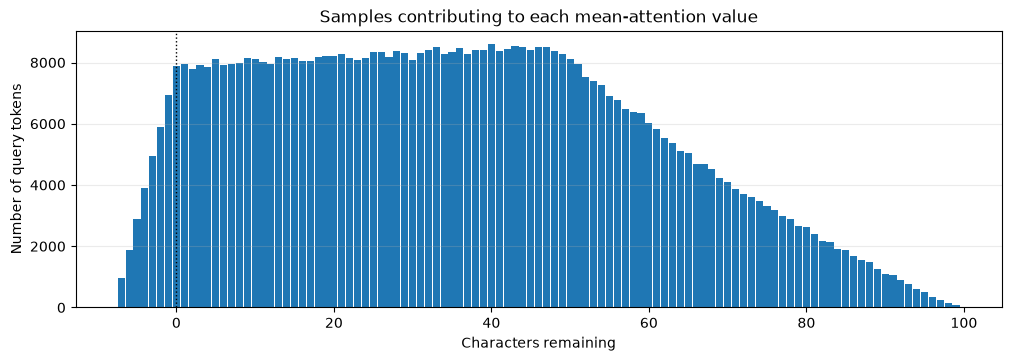

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5), constrained_layout=True)
ax.bar(plot_x, examples_per_value[observed], width=0.9)
ax.axvline(0, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Characters remaining")
ax.set_ylabel("Number of query tokens")
ax.set_title("Samples contributing to each mean-attention value")
ax.grid(axis="y", alpha=0.25)
plt.show()


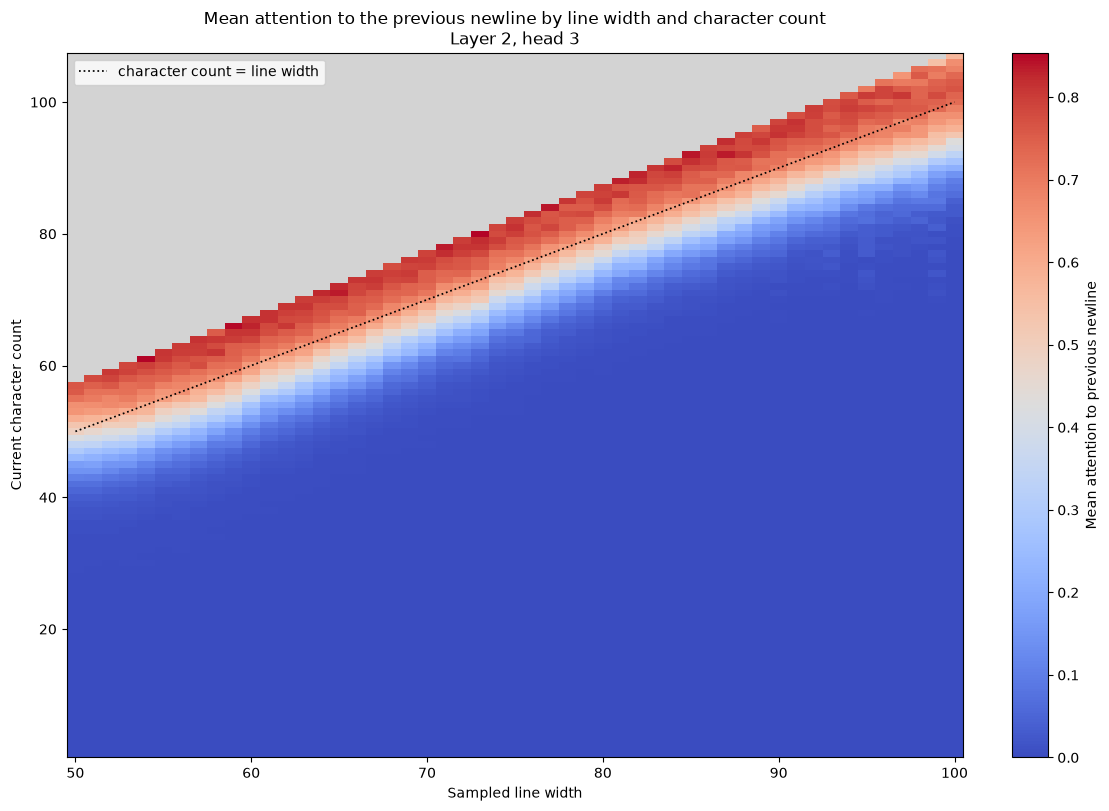

In [20]:
# Average attention to the previous newline for each
# (sampled line width, current character count) pair.
HEATMAP_LAYER = 2
HEATMAP_HEAD = 3
min_line_width, max_line_width = project_data.get_line_length_range(cfg["task"])
max_character_count = max_line_width + max_token_length - 1
n_line_widths = max_line_width - min_line_width + 1
attention_sum_by_width_and_count = np.zeros(
    (max_character_count, n_line_widths), dtype=np.float64
)
examples_by_width_and_count = np.zeros(
    (max_character_count, n_line_widths), dtype=np.int64
)
pattern_name = f"blocks.{HEATMAP_LAYER}.attn.hook_pattern"

with torch.no_grad():
    for start in range(0, N_SEQUENCES, COLLECTION_BATCH_SIZE):
        this_batch_size = min(COLLECTION_BATCH_SIZE, N_SEQUENCES - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size,
            vocab=vocab,
            task_cfg=cfg["task"],
            device=device,
            seed=DATA_SEED + start,
        )
        (
            batch_indices,
            query_indices,
            key_indices,
            remaining_values,
        ) = previous_newline_metadata(batch.tokens, batch.line_lengths)
        if len(remaining_values) == 0:
            continue

        line_widths = batch.line_lengths.detach().cpu().numpy()[batch_indices]
        character_counts = line_widths - remaining_values
        width_indices = line_widths - min_line_width
        count_indices = character_counts - 1
        _, cache = model.run_with_cache(
            batch.tokens,
            prepend_bos=False,
            names_filter=lambda name: name == pattern_name,
        )
        attention_values = (
            cache[pattern_name][
                batch_indices, HEATMAP_HEAD, query_indices, key_indices
            ]
            .detach()
            .cpu()
            .numpy()
        )
        np.add.at(
            attention_sum_by_width_and_count,
            (count_indices, width_indices),
            attention_values,
        )
        np.add.at(
            examples_by_width_and_count,
            (count_indices, width_indices),
            1,
        )

observed_pairs = examples_by_width_and_count > 0
mean_attention_by_width_and_count = np.full(
    attention_sum_by_width_and_count.shape, np.nan
)
mean_attention_by_width_and_count[observed_pairs] = (
    attention_sum_by_width_and_count[observed_pairs]
    / examples_by_width_and_count[observed_pairs]
)
masked_mean_attention = np.ma.masked_invalid(mean_attention_by_width_and_count)

cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad("lightgray")
fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=True)
image = ax.imshow(
    masked_mean_attention,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap=cmap,
    vmin=0.0,
    vmax=float(np.nanmax(mean_attention_by_width_and_count)),
    extent=(
        min_line_width - 0.5,
        max_line_width + 0.5,
        0.5,
        max_character_count + 0.5,
    ),
)
ax.plot(
    [min_line_width, max_line_width],
    [min_line_width, max_line_width],
    color="black",
    linestyle=":",
    linewidth=1.25,
    label="character count = line width",
)
ax.set_xlabel("Sampled line width")
ax.set_ylabel("Current character count")
ax.set_title(
    "Mean attention to the previous newline by line width and character count\n"
    f"Layer {HEATMAP_LAYER}, head {HEATMAP_HEAD}"
)
ax.legend(loc="upper left")
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Mean attention to previous newline")
plt.show()
